In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
%matplotlib inline
from pandas import DataFrame
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker
import math
import os

plt.rcParams['figure.dpi'] = 150

In [3]:
# angle bounds for determining cis vs trans configurations

cislower = -90
cisupper = 50
translower = 100
transupper = 240

has_weights = 1 # 0 = no, unreweighted data; 1 = yes, reweighted data

nsim = 10 # number of simulations

In [4]:
# Weights (unphos)

if has_weights ==1:
    ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/reweighting/weights_by_frame_MC-order10.dat', header=None)
    p_ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/reweighting/weights_by_frame_MC-order10.dat', header=None)

In [5]:
ctd_weights_combined = ctd_weights_combined_raw/ctd_weights_combined_raw.sum()
p_ctd_weights_combined = p_ctd_weights_combined_raw/p_ctd_weights_combined_raw.sum()

In [6]:
ctd = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/analysis/radgyr/radgyr_a_ctd.dat', sep = r'\s+')
ctd = ctd.drop(['1-23[Max]'],axis=1)

In [7]:
ctd.head()

,#Frame,1-23
0,1,11.5194
1,2,11.5243
2,3,11.5580
3,4,11.6236
4,5,11.6582


In [8]:
ctd_p = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/analysis/radgyr/radgyr_a_ctd_p.dat', sep = r'\s+')
ctd_p = ctd_p.drop(['1-23[Max]'],axis=1)

In [9]:
pmean = np.average(ctd_p["1-23"], weights=p_ctd_weights_combined[0])
npmean = np.average(ctd["1-23"], weights=ctd_weights_combined[0])

pstd = np.sqrt(np.cov(ctd_p["1-23"], aweights=p_ctd_weights_combined[0]))
npstd = np.sqrt(np.cov(ctd["1-23"], aweights=ctd_weights_combined[0]))

print("npmean: {}".format(npmean))
print("npstd: {}".format(npstd))
print("pmean: {}".format(pmean))
print("pstd: {}".format(pstd))

# ctd_p

npmean: 10.312182562121805
npstd: 1.9994284057792933
pmean: 11.223076248294964
pstd: 1.935558282507455


In [9]:
# ctd_p



phosphoryalted vs unphosphorylated

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


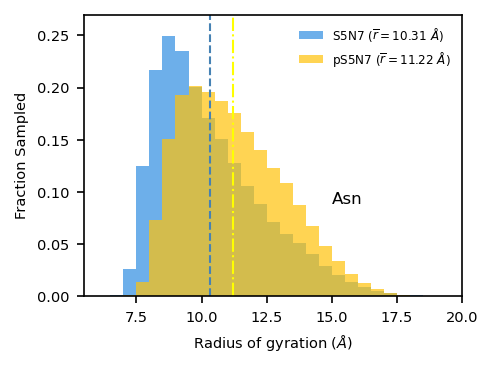

In [10]:
plt.figure()

binedges = np.arange(6,20,0.5)

plt.hist(ctd['1-23'], bins = binedges, weights = ctd_weights_combined[0], density=True , color="#0C7BDC", label=r"S5N7 ($\overline{r} = $"+"{} $\AA$)".format(round(npmean, 2)), alpha=0.6)
plt.hist(ctd_p['1-23'], bins = binedges, weights = p_ctd_weights_combined[0], density=True , color="#FFC20A", label=r"pS5N7 ($\overline{r} = $"+"{} $\AA$)".format(round(pmean, 2)), alpha=0.7)

plt.axvline(npmean, color='steelblue', ls='--', linewidth=1)
plt.axvline(pmean, color='yellow', ls='-.', linewidth=1)
plt.ylim([0, 0.27])
plt.xlim([5.5,20])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled', fontsize=7)
plt.xlabel('Radius of gyration ($\AA$)', fontsize=7)
#plt.title('Radius of Gyration (Asn)')
plt.legend(loc="upper right", fontsize=5.75, frameon=False)
plt.text(15, 0.1, 'Asn', fontsize=8, verticalalignment='top')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('radgyr_asn.png', dpi=300, bbox_inches='tight')

plt.show()

In [12]:
pmean - npmean

0.9108936861731589

In [13]:
over_time_p = ctd_p.drop(columns=["#Frame"]) 
over_time = ctd.drop(columns=["#Frame"]) 

In [14]:
over_time_p

,1-23
0,9.1708
1,9.1652
2,9.1715
3,9.1527
4,9.1637
...,...
48999995,12.6711
48999996,12.6850
48999997,12.7260
48999998,12.7302


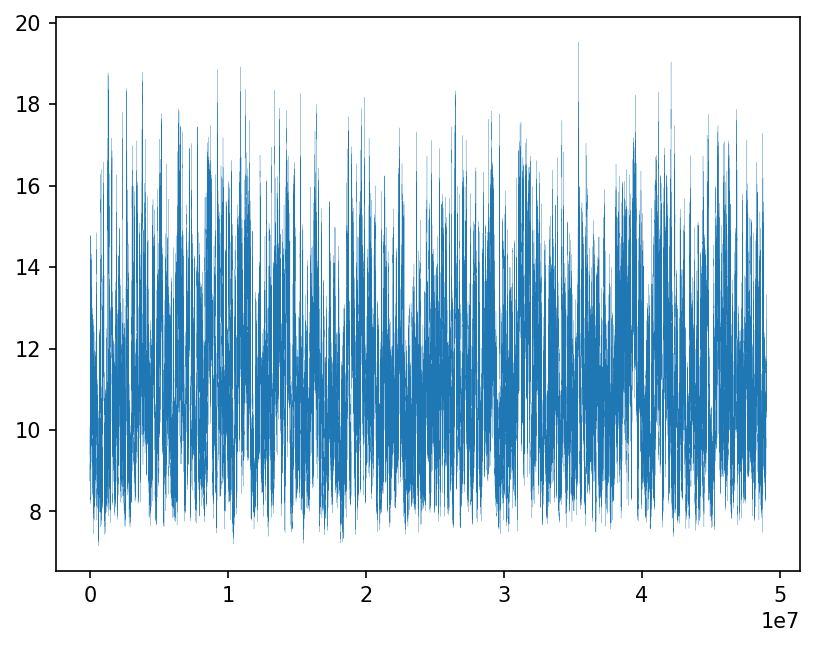

In [15]:
size = len(over_time_p.index)
plt.plot(over_time_p.index[:size], over_time_p["1-23"][:size],linewidth=0.1)


In [16]:
max_radgyr_p = max(over_time_p["1-23"][:100000])
min_radgyr_p = min(over_time_p["1-23"][:100000])

over_time_p.loc[(over_time_p["1-23"] == max_radgyr_p)]

,1-23
48137,14.7752
794870,14.7752
797958,14.7752
971018,14.7752
1340450,14.7752
...,...
47663559,14.7752
47932981,14.7752
48759483,14.7752
48761018,14.7752


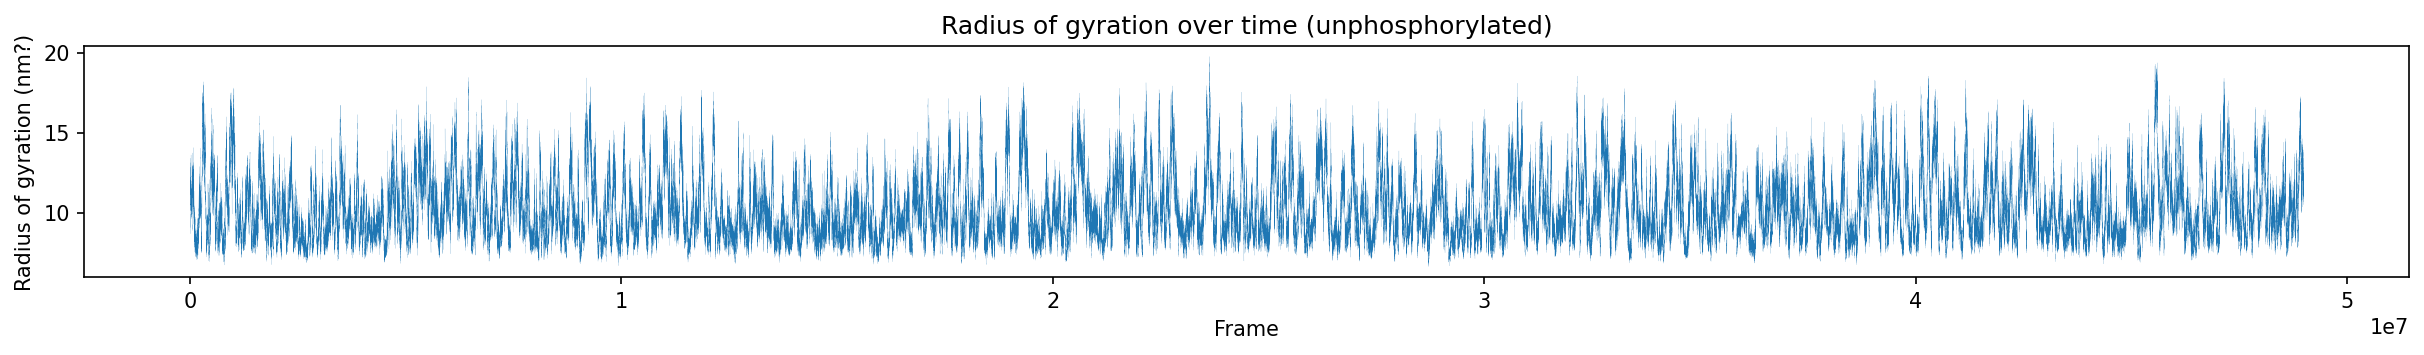

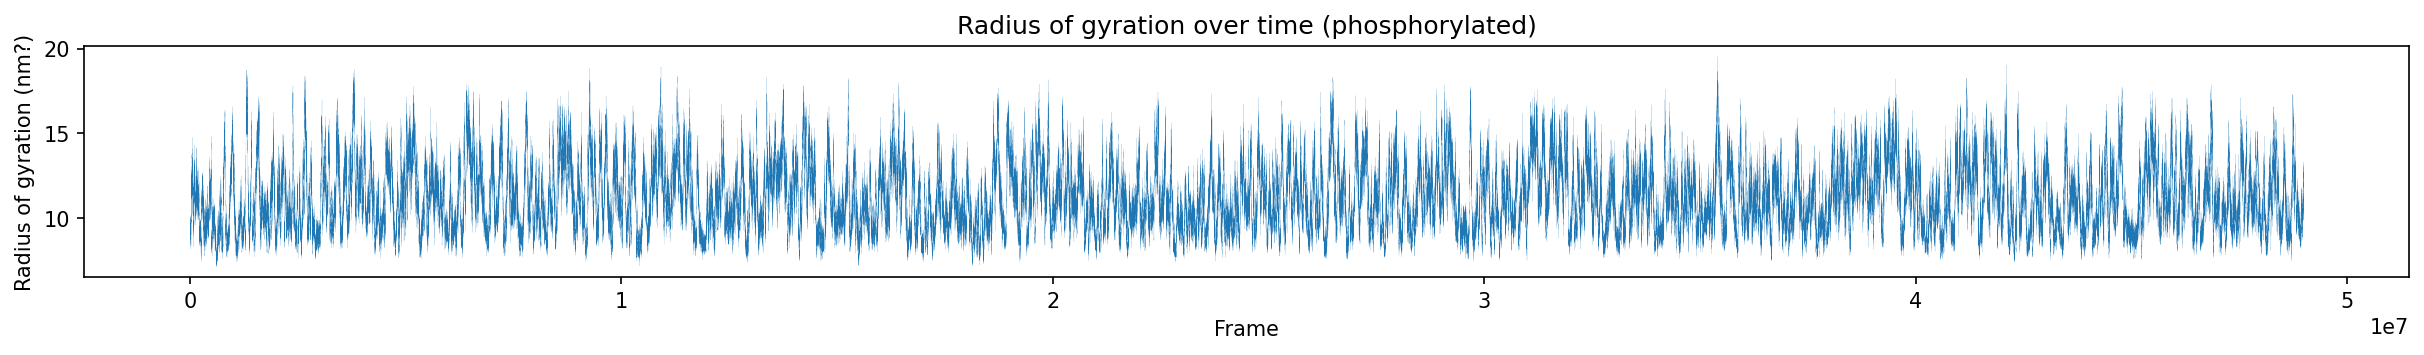

In [17]:
size = len(over_time.index)
size_p = len(over_time_p.index)

fig = plt.figure(figsize=(20, 2))
ax = fig.add_subplot(111)
ax.plot(over_time.index[:size], over_time["1-23"][:size], linewidth=0.05)
plt.title('Radius of gyration over time (unphosphorylated)')
plt.xlabel('Frame')
plt.ylabel('Radius of gyration (nm?)')
ax


fig = plt.figure(figsize=(20, 2))
ax = fig.add_subplot(111)
ax.plot(over_time.index[:size], over_time_p["1-23"][:size], linewidth=0.05)
plt.title('Radius of gyration over time (phosphorylated)')
plt.xlabel('Frame')
plt.ylabel('Radius of gyration (nm?)')
ax
plt.show()

# Turn vs no turn

In [10]:
params = [{'sep':r'\s+', 'low_memory':False}, {'engine':'c'}][0]

ctd_secstruc = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/analysis/turn/ctd_sec.out', **params)
ctd_phos_secstruc = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/analysis/turn/ctd_p_sec.out', **params)

In [11]:
ctd

,#Frame,1-23
0,1,11.5194
1,2,11.5243
2,3,11.5580
3,4,11.6236
4,5,11.6582
...,...,...
48999995,48999996,13.4979
48999996,48999997,13.5375
48999997,48999998,13.5822
48999998,48999999,13.5828


In [12]:
ctd['Pro13 secstruc'] = ctd_secstruc['PRO:14']

In [13]:
ctd['weights'] = ctd_weights_combined[0]

In [14]:
ctd

,#Frame,1-23,Pro13 secstruc,weights
0,1,11.5194,0,5.568765e-09
1,2,11.5243,0,1.472184e-08
2,3,11.5580,0,9.697759e-09
3,4,11.6236,0,3.353217e-08
4,5,11.6582,0,8.338822e-09
...,...,...,...,...
48999995,48999996,13.4979,0,1.317516e-08
48999996,48999997,13.5375,0,1.811567e-08
48999997,48999998,13.5822,0,3.887373e-08
48999998,48999999,13.5828,0,2.536682e-08


In [15]:
ctd_p['Pro13 secstruc'] = ctd_phos_secstruc['PRO:14']

In [16]:
ctd_p['weights'] = p_ctd_weights_combined[0]

In [17]:
ctd_w_turn = ctd[ctd['Pro13 secstruc'] == 'T']

In [18]:
ctd_w_turn['weights'] = ctd_w_turn['weights']/ctd_w_turn['weights'].sum()

/tmp/ipykernel_591160/385076149.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctd_w_turn['weights'] = ctd_w_turn['weights']/ctd_w_turn['weights'].sum()


In [19]:
ctd_p_w_turn = ctd_p[ctd_p['Pro13 secstruc'] == 'T']

In [20]:
ctd_p_w_turn['weights'] = ctd_p_w_turn['weights']/ctd_p_w_turn['weights'].sum()

/tmp/ipykernel_591160/67018472.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctd_p_w_turn['weights'] = ctd_p_w_turn['weights']/ctd_p_w_turn['weights'].sum()


In [21]:
pmean_w_turn = np.average(ctd_p_w_turn["1-23"], weights=ctd_p_w_turn['weights'])
npmean_w_turn = np.average(ctd_w_turn["1-23"], weights=ctd_w_turn['weights'])

pstd_w_turn = np.sqrt(np.cov(ctd_p_w_turn["1-23"], aweights=ctd_p_w_turn['weights']))
npstd_w_turn = np.sqrt(np.cov(ctd_w_turn["1-23"], aweights=ctd_w_turn['weights']))

print("npmean: {}".format(npmean_w_turn))
print("npstd: {}".format(npstd_w_turn))
print("pmean: {}".format(pmean_w_turn))
print("pstd: {}".format(pstd_w_turn))


npmean: 9.668833373093129
npstd: 1.5071701195168845
pmean: 10.505112214276696
pstd: 1.544466116359177


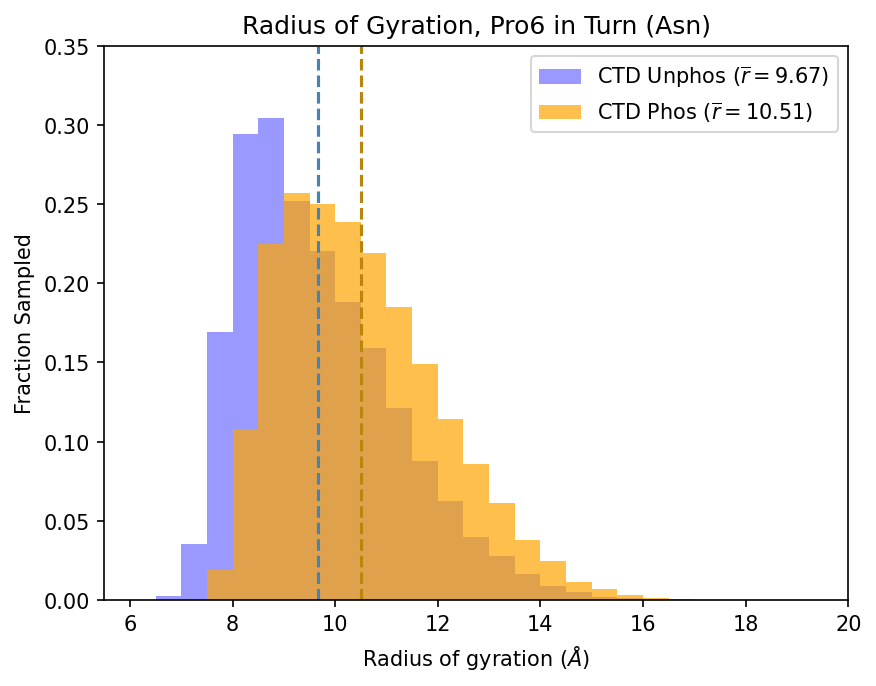

In [23]:
binedges = np.arange(6,20,0.5)

plt.hist(ctd_w_turn["1-23"], bins = binedges, weights = ctd_w_turn['weights'], density=True , color="blue", label=r"CTD Unphos ($\overline{r} = $"+"{})".format(round(npmean_w_turn, 2)), alpha=0.4)
plt.hist(ctd_p_w_turn["1-23"], bins = binedges, weights = ctd_p_w_turn['weights'], density=True , color="orange", label=r"CTD Phos ($\overline{r} = $"+"{})".format(round(pmean_w_turn, 2)), alpha=0.7)

plt.axvline(npmean_w_turn, color='steelblue', ls='--')
plt.axvline(pmean_w_turn, color='darkgoldenrod', ls='--')
plt.ylim([0, 0.35])
plt.xlim([5.5,20])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('Radius of gyration ($\AA$)')
plt.title('Radius of Gyration, Pro6 in Turn (Asn)')
plt.legend(loc="upper right", fontsize=10)
plt.show()
# filename = "radgyr_asn_1.pdf"
# path="/home/wbarr/data/ctd_project/Figure_July_2023/"    # remember to have a trailing '/' !!!!

# overwrite = False

# if not overwrite and os.path.exists(path + filename):
#     raise FileExistsError("File already exists and overwrite is set to False.")
# else:
#     plt.savefig(path + filename, format="pdf", bbox_inches="tight")
#     plt.show()
#     print("File Saved.")

In [22]:
ctd_wo_turn = ctd[ctd['Pro13 secstruc'] != 'T']

In [23]:
ctd_wo_turn['weights'] = ctd_wo_turn['weights']/ctd_wo_turn['weights'].sum()

/tmp/ipykernel_591160/121632409.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctd_wo_turn['weights'] = ctd_wo_turn['weights']/ctd_wo_turn['weights'].sum()


In [24]:
ctd_p_wo_turn = ctd_p[ctd_p['Pro13 secstruc'] != 'T']

In [25]:
ctd_p_wo_turn['weights'] = ctd_p_wo_turn['weights']/ctd_p_wo_turn['weights'].sum()

/tmp/ipykernel_591160/129144290.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ctd_p_wo_turn['weights'] = ctd_p_wo_turn['weights']/ctd_p_wo_turn['weights'].sum()


In [26]:
pmean_wo_turn = np.average(ctd_p_wo_turn["1-23"], weights=ctd_p_wo_turn['weights'])
npmean_wo_turn = np.average(ctd_wo_turn["1-23"], weights=ctd_wo_turn['weights'])

pstd_wo_turn = np.sqrt(np.cov(ctd_p_wo_turn["1-23"], aweights=ctd_p_wo_turn['weights']))
npstd_wo_turn = np.sqrt(np.cov(ctd_wo_turn["1-23"], aweights=ctd_wo_turn['weights']))

print("npmean: {}".format(npmean_wo_turn))
print("npstd: {}".format(npstd_wo_turn))
print("pmean: {}".format(pmean_wo_turn))
print("pstd: {}".format(pstd_wo_turn))

npmean: 10.411613070474653
npstd: 2.0471048526303206
pmean: 11.44013879306157
pstd: 1.9886935053735457


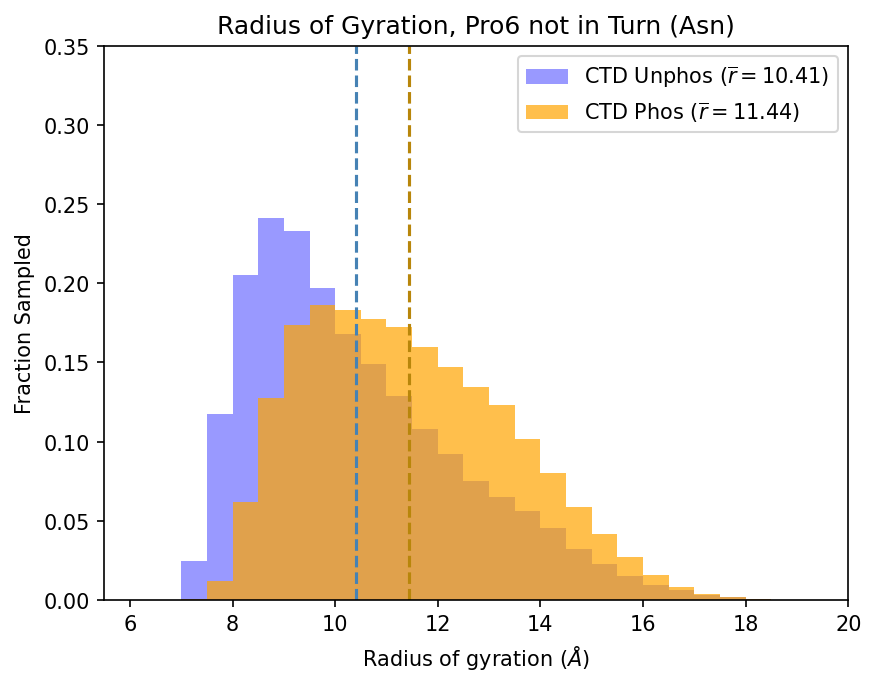

In [27]:
binedges = np.arange(6,20,0.5)

plt.hist(ctd_wo_turn["1-23"], bins = binedges, density=True , weights = ctd_wo_turn['weights'], color="blue", label=r"CTD Unphos ($\overline{r} = $"+"{})".format(round(npmean_wo_turn, 2)), alpha=0.4)
plt.hist(ctd_p_wo_turn["1-23"], bins = binedges, density=True , weights = ctd_p_wo_turn['weights'], color="orange", label=r"CTD Phos ($\overline{r} = $"+"{})".format(round(pmean_wo_turn, 2)), alpha=0.7)

plt.axvline(npmean_wo_turn, color='steelblue', ls='--')
plt.axvline(pmean_wo_turn, color='darkgoldenrod', ls='--')
plt.ylim([0, 0.35])
plt.xlim([5.5,20])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled')
plt.xlabel('Radius of gyration ($\AA$)')
plt.title('Radius of Gyration, Pro6 not in Turn (Asn)')
plt.legend(loc="upper right", fontsize=10)
plt.show()
# filename = "radgyr_asn_1.pdf"
# path="/home/wbarr/data/ctd_project/Figure_July_2023/"    # remember to have a trailing '/' !!!!

# overwrite = False

# if not overwrite and os.path.exists(path + filename):
#     raise FileExistsError("File already exists and overwrite is set to False.")
# else:
#     plt.savefig(path + filename, format="pdf", bbox_inches="tight")
#     plt.show()
#     print("File Saved.")

## Compare turn/no turn on same plot

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


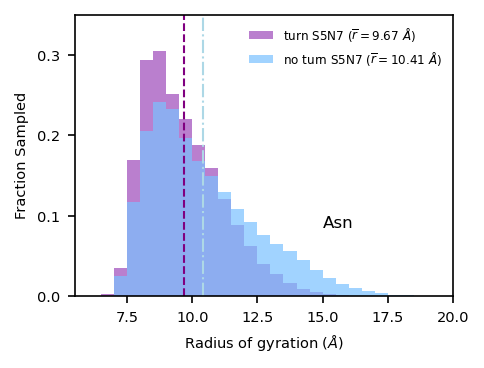

In [30]:
plt.figure()

binedges = np.arange(6,20,0.5)

plt.hist(ctd_w_turn["1-23"], bins = binedges, density=True , weights = ctd_w_turn['weights'], color="#77019E", label=r"turn S5N7 ($\overline{r} = $"+"{} $\AA$)".format(round(npmean_w_turn, 2)), alpha=0.5)
plt.hist(ctd_wo_turn["1-23"], bins = binedges, density=True , weights = ctd_wo_turn['weights'], color="#7AC1FF", label=r"no turn S5N7 ($\overline{r} = $"+"{} $\AA$)".format(round(npmean_wo_turn, 2)), alpha=0.7)

plt.axvline(npmean_w_turn, color='purple', ls='--', linewidth=1)
plt.axvline(npmean_wo_turn, color='lightblue', ls='-.', linewidth=1)
plt.ylim([0, 0.35])
plt.xlim([5.5,20])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled', fontsize=7)
plt.xlabel('Radius of gyration ($\AA$)', fontsize=7)
#plt.title('Unphosphorylated (Asn)')
plt.legend(loc="upper right", fontsize=5.75, frameon=False)
plt.text(15, 0.1, 'Asn', fontsize=8, verticalalignment='top')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('radgyr_asn_turnnoturn.png', dpi=300, bbox_inches='tight')

plt.show()

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


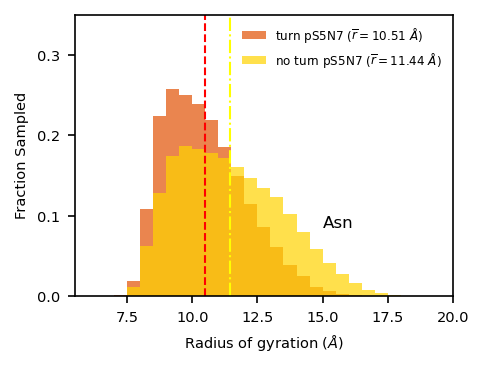

In [28]:
plt.figure()

binedges = np.arange(6,20,0.5)

plt.hist(ctd_p_w_turn["1-23"], bins = binedges, density=True , weights = ctd_p_w_turn['weights'], color="#E25105", label=r"turn pS5N7 ($\overline{r} = $"+"{} $\AA$)".format(round(pmean_w_turn, 2)), alpha=0.7)
plt.hist(ctd_p_wo_turn["1-23"], bins = binedges, density=True , weights = ctd_p_wo_turn['weights'], color="#FFD400", label=r"no turn pS5N7 ($\overline{r} = $"+"{} $\AA$)".format(round(pmean_wo_turn, 2)), alpha=0.7)

plt.axvline(pmean_w_turn, color='red', ls='--', linewidth=1)
plt.axvline(pmean_wo_turn, color='yellow', ls='-.', linewidth=1)
plt.ylim([0, 0.35])
plt.xlim([5.5,20])
# plt.text(15.5, 0.24, r"$\overline{r_{phos}}=$" + str(round(pmean, 3)), fontsize=9, horizontalalignment='right')
# plt.text(15.5, 0.255, r"$\overline{r_{unphos}}=$" + str(round(npmean, 2)), fontsize=9, horizontalalignment='right')

#plt.axvline(ctd['1-23'].mean(), color='k', linestyle='solid', linewidth=1, label = "CTD mean")
#plt.axvline(ctd_cisp['1-23'].mean(), color='k', linestyle='dotted', linewidth=1, label = "CTD Phos mean")
plt.ylabel('Fraction Sampled', fontsize=7)
plt.xlabel('Radius of gyration ($\AA$)', fontsize=7)
#plt.title('Phosphorylated (Asn)')
plt.legend(loc="upper right", fontsize=5.75, frameon=False)
plt.text(15, 0.1, 'Asn', fontsize=8, verticalalignment='top')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('p_radgyr_asn_turnnoturn.png', dpi=300, bbox_inches='tight')

plt.show()

# Radgyr vs number of prolines in *cis*

In [7]:
ctd_omega_angles_raw = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/analysis/turn/ctd_dihedral_Omega.dat', sep = r'\s+')
ctd_phos_omega_angles_raw = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/analysis/turn/ctd_dihedral_Omega.dat', sep = r'\s+')

In [8]:
df_360 = ctd_omega_angles_raw.copy()
# loop through columns to convert numbers below -90
for col in df_360:
    df_360.loc[df_360[col] < -90, col] += 360  # Convert negative angles to a 0-360 range
    df_360[col] = round(df_360[col])  # Round angles to the nearest integer

In [9]:
df_360_phos = ctd_phos_omega_angles_raw # Create a new column to hold the 360-degree adjusted omega values
# loop through columns to convert numbers below -90
for col in df_360_phos:
    df_360_phos.loc[df_360_phos[col] < -90, col] += 360  # Convert negative angles to a 0-360 range
    df_360_phos[col] = round(df_360_phos[col])  # Round angles to the nearest integer

In [10]:
# retaining omega angle values
ctd_phos_omega_angles = df_360_phos.copy()
ctd_omega_angles = df_360.copy()

In [ ]:
# labelling configurationgs of omega angles
temp_angles = ctd_phos_omega_angles.copy()

ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= translower) & (temp_angles.iloc[:,1:] <= transupper)] = "trans"
ctd_phos_omega_angles[(ctd_phos_omega_angles.iloc[:,1:] != "cis") & (ctd_phos_omega_angles.iloc[:,1:] != "trans")] = "neither"

temp_angles = ctd_omega_angles.copy()

ctd_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
ctd_omega_angles[(temp_angles.iloc[:,1:] >= translower) & (temp_angles.iloc[:,1:] <= transupper)] = "trans"
ctd_omega_angles[(ctd_omega_angles.iloc[:,1:] != "cis") & (ctd_omega_angles.iloc[:,1:] != "trans")] = "neither"

/tmp/ipykernel_589785/3590104210.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cis' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"


In [ ]:
ctd_omega_angles.head()

In [ ]:
# ctd_num_cis = pd.DataFrame((ctd_omega_angles['omega:4'] == 'cis').astype(int) + (ctd_omega_angles['omega:7'] == 'cis').astype(int)
# + (ctd_omega_angles['omega:11'] == 'cis').astype(int) + (ctd_omega_angles['omega:14'] == 'cis').astype(int)
# + (ctd_omega_angles['omega:18'] == 'cis').astype(int) + (ctd_omega_angles['omega:21'] == 'cis').astype(int))

In [ ]:
# ctd_phos_num_cis = pd.DataFrame((ctd_phos_omega_angles['omega:4'] == 'cis').astype(int) + (ctd_phos_omega_angles['omega:7'] == 'cis').astype(int)
# + (ctd_phos_omega_angles['omega:11'] == 'cis').astype(int) + (ctd_phos_omega_angles['omega:14'] == 'cis').astype(int)
# + (ctd_phos_omega_angles['omega:18'] == 'cis').astype(int) + (ctd_phos_omega_angles['omega:21'] == 'cis').astype(int))

In [ ]:
#ctd_num_cis.head()

In [ ]:
# ctd['num Pro in cis'] = ctd_num_cis[0]
# ctd_p['num Pro in cis'] = ctd_phos_num_cis[0]

In [ ]:
ctd

In [ ]:
# plt.figure()
# plt.hist2d(ctd['num Pro in cis'], ctd['1-23'], weights = ctd['weights'], bins=[np.arange(-0.5, 7, 1), np.arange(6, 20, 0.5)])
# plt.colorbar()
# plt.xlabel("# of Prolines in cis")
# plt.ylabel("Radius of gyration")
# plt.title("Unphosphorylated")
# plt.show()

In [ ]:
# plt.figure()
# plt.hist2d(ctd_p['num Pro in cis'], ctd_p['1-23'], weights = ctd_p['weights'], bins=[np.arange(-0.5, 7, 1), np.arange(6, 20, 0.5)])
# plt.colorbar()
# plt.xlabel("# of Prolines in cis")
# plt.ylabel("Radius of gyration")
# plt.title("Phosphorylated")
# plt.show()

In [21]:
ctd

,#Frame,1-23,num Pro in cis
0,1,11.5194,0
1,2,11.5243,0
2,3,11.5580,0
3,4,11.6236,0
4,5,11.6582,0
...,...,...,...
48999995,48999996,13.4979,0
48999996,48999997,13.5375,0
48999997,48999998,13.5822,0
48999998,48999999,13.5828,0


In [22]:
ctd_sim_list = np.array_split(ctd, nsim)
p_ctd_sim_list = np.array_split(ctd_p, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [23]:
# Define column names
columns = ['cis_0', 'cis_1', 'cis_2', 'cis_3', 'cis_4', 'cis_5', 'cis_6']

# Create an empty DataFrame with 2 rows and 5 columns
cis_radgyr = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

In [34]:
cis_radgyr

NameError: name 'cis_radgyr' is not defined

In [25]:
ctd_sim_list[0]

,#Frame,1-23,num Pro in cis
0,1,11.5194,0
1,2,11.5243,0
2,3,11.5580,0
3,4,11.6236,0
4,5,11.6582,0
...,...,...,...
4899995,4899996,8.7994,2
4899996,4899997,8.8483,2
4899997,4899998,8.8408,1
4899998,4899999,8.8132,2


In [26]:
i = 0
for sim in ctd_sim_list:
    
    cis_0_true = ((sim['num Pro in cis'] == 0)*sim['weights']).sum()
    cis_1_true = ((sim['num Pro in cis'] == 1)*sim['weights']).sum()
    cis_2_true = ((sim['num Pro in cis'] == 2)*sim['weights']).sum()
    cis_3_true = ((sim['num Pro in cis'] == 3)*sim['weights']).sum()
    cis_4_true = ((sim['num Pro in cis'] == 4)*sim['weights']).sum()
    cis_5_true = ((sim['num Pro in cis'] == 5)*sim['weights']).sum()
    cis_6_true = ((sim['num Pro in cis'] == 6)*sim['weights']).sum()

    mean = sim['1-23'].mul((sim['num Pro in cis'] == 0)*sim['weights'], 0).sum()/cis_0_true
    cis_radgyr.at[i, 'cis_0'] = mean
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 1)*sim['weights'], 0).sum()/cis_1_true
    cis_radgyr.at[i, 'cis_1'] = mean
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 2)*sim['weights'], 0).sum()/cis_2_true
    cis_radgyr.at[i, 'cis_2'] = mean
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 3)*sim['weights'], 0).sum()/cis_3_true
    cis_radgyr.at[i, 'cis_3'] = mean
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 4)*sim['weights'], 0).sum()/cis_4_true
    cis_radgyr.at[i, 'cis_4'] = mean
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 5)*sim['weights'], 0).sum()/cis_5_true
    cis_radgyr.at[i, 'cis_5'] = mean
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 6)*sim['weights'], 0).sum()/cis_6_true
    cis_radgyr.at[i, 'cis_6'] = mean
    
    i += 1

KeyError: 'weights'

In [ ]:
cis_radgyr

In [ ]:
# Calculate the SEM (standard error of the mean)
mean_values = cis_radgyr.mean()
sem_values = cis_radgyr.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([cis_radgyr, pd.DataFrame([mean_values], index=['mean'])])
cis_radgyr_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [ ]:
cis_radgyr_final

In [ ]:
# Define column names
columns = ['cis_0', 'cis_1', 'cis_2', 'cis_3', 'cis_4', 'cis_5', 'cis_6']

# Create an empty DataFrame with 2 rows and 5 columns
p_cis_radgyr = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

In [ ]:
i = 0
for sim in p_ctd_sim_list:
    
    cis_0_true = ((sim['num Pro in cis'] == 0)*sim['weights']).sum()
    cis_1_true = ((sim['num Pro in cis'] == 1)*sim['weights']).sum()
    cis_2_true = ((sim['num Pro in cis'] == 2)*sim['weights']).sum()
    cis_3_true = ((sim['num Pro in cis'] == 3)*sim['weights']).sum()
    cis_4_true = ((sim['num Pro in cis'] == 4)*sim['weights']).sum()
    cis_5_true = ((sim['num Pro in cis'] == 5)*sim['weights']).sum()
    cis_6_true = ((sim['num Pro in cis'] == 6)*sim['weights']).sum()

    mean = sim['1-23'].mul((sim['num Pro in cis'] == 0)*sim['weights'], 0).sum()/cis_0_true
    p_cis_radgyr.at[i, 'cis_0'] = mean
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 1)*sim['weights'], 0).sum()/cis_1_true
    p_cis_radgyr.at[i, 'cis_1'] = mean
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 2)*sim['weights'], 0).sum()/cis_2_true
    p_cis_radgyr.at[i, 'cis_2'] = mean
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 3)*sim['weights'], 0).sum()/cis_3_true
    p_cis_radgyr.at[i, 'cis_3'] = mean
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 4)*sim['weights'], 0).sum()/cis_4_true
    p_cis_radgyr.at[i, 'cis_4'] = mean
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 5)*sim['weights'], 0).sum()/cis_5_true
    p_cis_radgyr.at[i, 'cis_5'] = mean
    mean = sim['1-23'].mul((sim['num Pro in cis'] == 6)*sim['weights'], 0).sum()/cis_6_true
    p_cis_radgyr.at[i, 'cis_6'] = mean
    
    i += 1

In [ ]:
p_cis_radgyr

In [ ]:
# Calculate the SEM (standard error of the mean)
mean_values = p_cis_radgyr.mean()
sem_values = p_cis_radgyr.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([p_cis_radgyr, pd.DataFrame([mean_values], index=['mean'])])
p_cis_radgyr_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [ ]:
p_cis_radgyr_final

In [ ]:
x_rename = np.arange(0,7)

plt.figure()
cis_radgyr_final.loc['mean'].plot(marker='o', ls='None', yerr=cis_radgyr_final.loc['sem'])
plt.ylim(8, 12)
plt.xlim(-0.5, 6.5)
plt.xticks(range(len(x_rename)), x_rename)
plt.xlabel('# of prolines in cis')
plt.ylabel('Average radius of gyration')
plt.title('Unphosphorylated')
plt.show()

In [ ]:
plt.figure()
p_cis_radgyr_final.loc['mean'].plot(marker='o', ls='None', yerr=p_cis_radgyr_final.loc['sem'])
plt.ylim(8, 12)
plt.xlim(-0.5, 6.5)
plt.xticks(range(len(x_rename)), x_rename)
plt.xlabel('# of prolines in cis')
plt.ylabel('Average radius of gyration')
plt.title('Phosphorylated')
plt.show()